In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PATH_BIASED   = '/data/shared/fsibilla/clean_code/Q1/biased/across_experiments_eval/metrics_all_experiments.csv'
PATH_UNBIASED = '/data/shared/fsibilla/clean_code/Q1/across_experiments_eval/metrics_all_experiments.csv'

df_biased   = pd.read_csv(PATH_BIASED)
df_unbiased = pd.read_csv(PATH_UNBIASED)

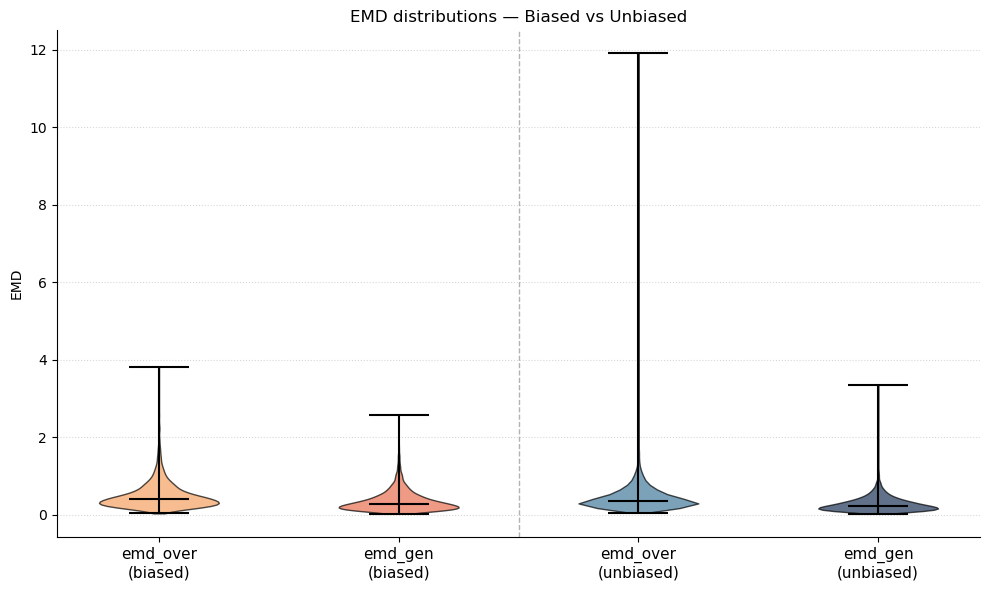

In [2]:
data = [
    df_biased['emd_over'].dropna().values,
    df_biased['emd_gen'].dropna().values,
    df_unbiased['emd_over'].dropna().values,
    df_unbiased['emd_gen'].dropna().values,
]

labels = ['emd_over\n(biased)', 'emd_gen\n(biased)', 'emd_over\n(unbiased)', 'emd_gen\n(unbiased)']
colors = ['#F4A261', '#E76F51', '#457B9D', '#1D3557']

fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot(data, positions=[1, 2, 3, 4], showmedians=True, showextrema=True)

for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

for part_name in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
    parts[part_name].set_edgecolor('black')

ax.axvline(2.5, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('EMD')
ax.set_title('EMD distributions — Biased vs Unbiased')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

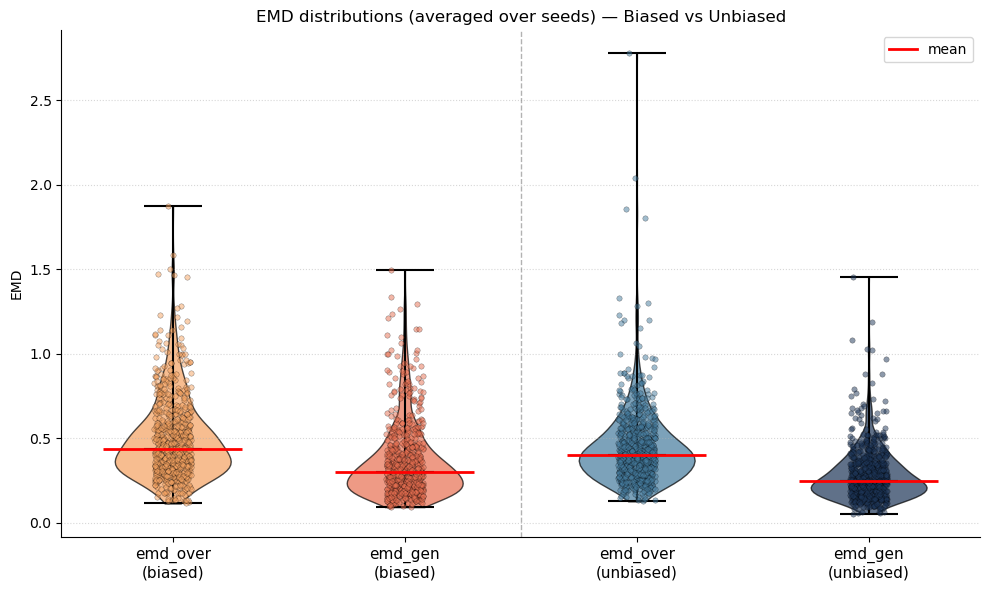

In [3]:
group_cols = ['adm1_code', 'target', 'experiment_id']

df_b = df_biased.groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index()
df_u = df_unbiased.groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index()

data = [
    df_b['emd_over'].dropna().values,
    df_b['emd_gen'].dropna().values,
    df_u['emd_over'].dropna().values,
    df_u['emd_gen'].dropna().values,
]

labels = ['emd_over\n(biased)', 'emd_gen\n(biased)', 'emd_over\n(unbiased)', 'emd_gen\n(unbiased)']
colors = ['#F4A261', '#E76F51', '#457B9D', '#1D3557']

fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot(data, positions=[1, 2, 3, 4], showmedians=True, showextrema=True)

for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

for part_name in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
    parts[part_name].set_edgecolor('black')

# jittered individual points
np.random.seed(42)
for i, (d, col) in enumerate(zip(data, colors), start=1):
    jitter = np.random.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d,
               color=col, edgecolor='black', linewidth=0.3,
               s=15, alpha=0.5, zorder=3)

# horizontal lines at the mean
for i, d in enumerate(data, start=1):
    ax.hlines(np.median(d), i - 0.3, i + 0.3,
              colors='red', linewidth=2, zorder=4, label='mean' if i == 1 else None)

ax.axvline(2.5, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('EMD')
ax.set_title('EMD distributions (averaged over seeds) — Biased vs Unbiased')
ax.legend(handles=[plt.Line2D([0], [0], color='red', linewidth=2, label='mean')])
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

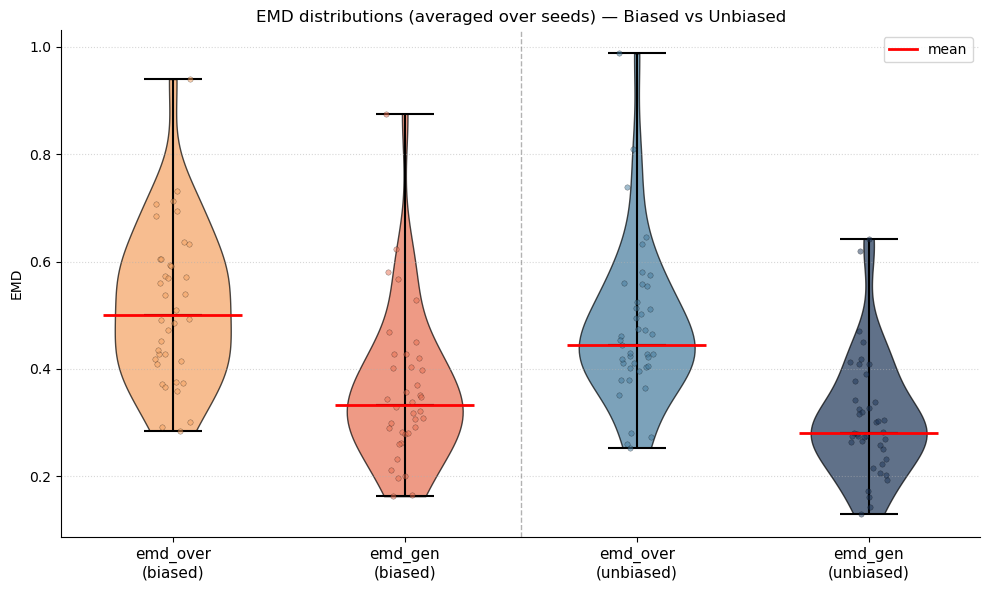

In [4]:
group_cols = ['target', 'experiment_id']

df_b = df_biased.groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index()
df_u = df_unbiased.groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index()

data = [
    df_b['emd_over'].dropna().values,
    df_b['emd_gen'].dropna().values,
    df_u['emd_over'].dropna().values,
    df_u['emd_gen'].dropna().values,
]

labels = ['emd_over\n(biased)', 'emd_gen\n(biased)', 'emd_over\n(unbiased)', 'emd_gen\n(unbiased)']
colors = ['#F4A261', '#E76F51', '#457B9D', '#1D3557']

fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot(data, positions=[1, 2, 3, 4], showmedians=True, showextrema=True)

for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

for part_name in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
    parts[part_name].set_edgecolor('black')

# jittered individual points
np.random.seed(42)
for i, (d, col) in enumerate(zip(data, colors), start=1):
    jitter = np.random.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d,
               color=col, edgecolor='black', linewidth=0.3,
               s=15, alpha=0.5, zorder=3)

# horizontal lines at the mean
for i, d in enumerate(data, start=1):
    ax.hlines(np.median(d), i - 0.3, i + 0.3,
              colors='red', linewidth=2, zorder=4, label='median' if i == 1 else None)

ax.axvline(2.5, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('EMD')
ax.set_title('EMD distributions (averaged over seeds) — Biased vs Unbiased')
ax.legend(handles=[plt.Line2D([0], [0], color='red', linewidth=2, label='mean')])
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

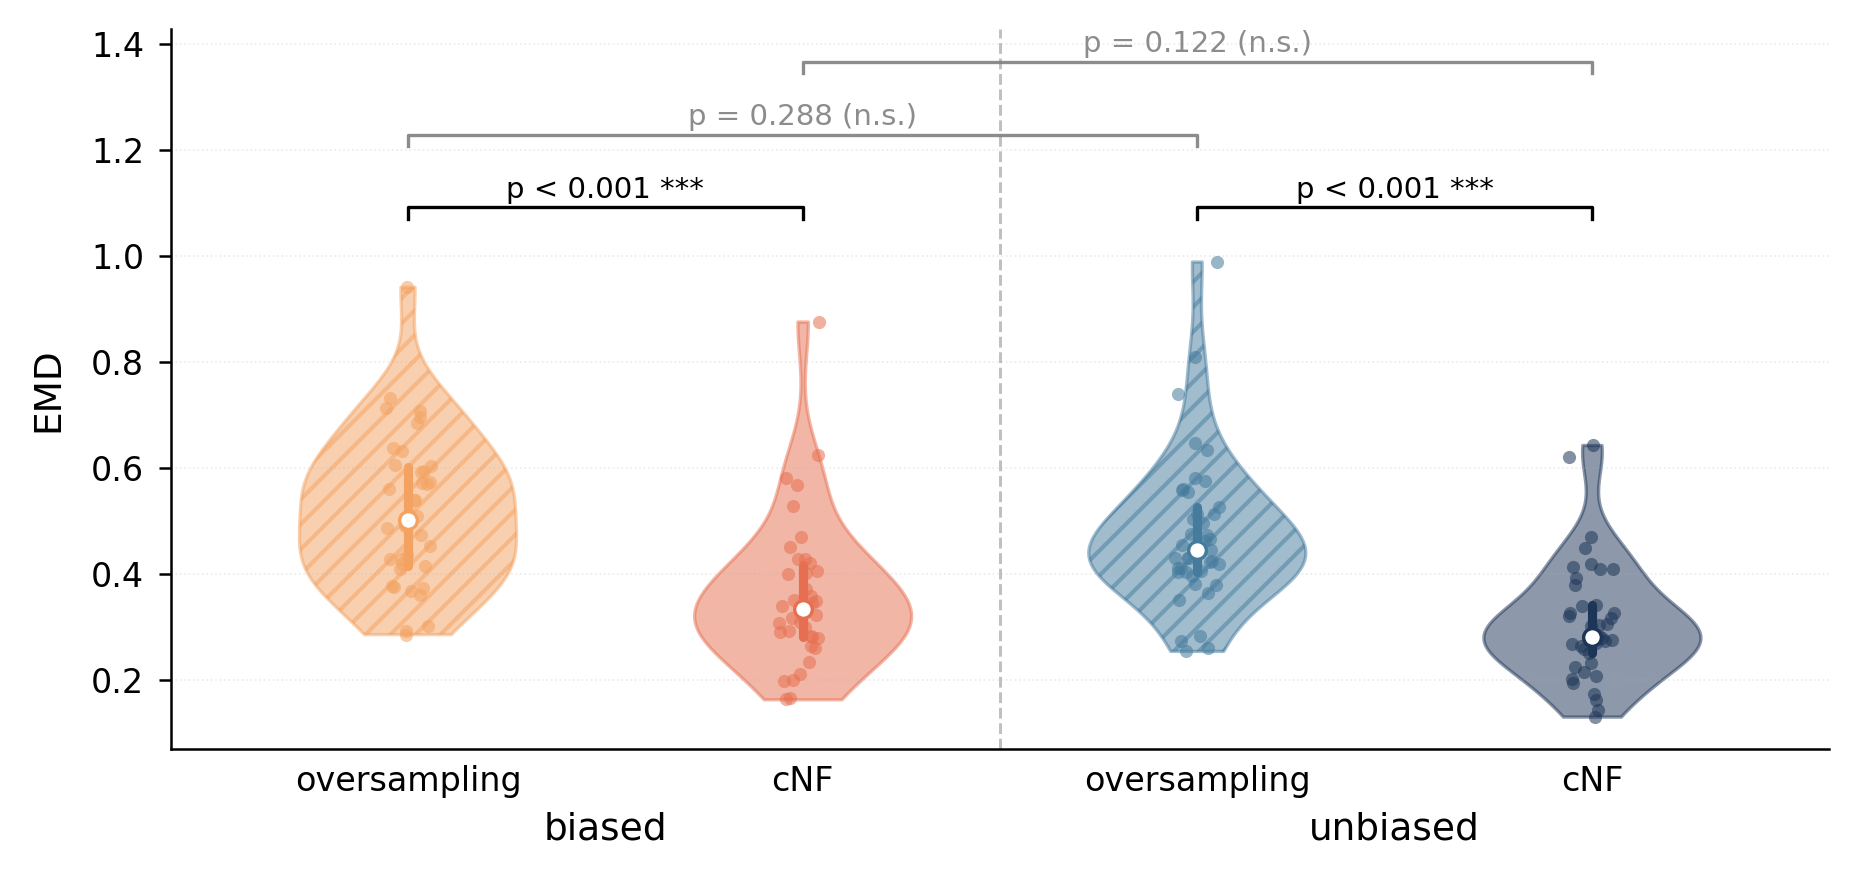

In [20]:
from scipy import stats

group_cols = ['target', 'experiment_id']
df_b = df_biased.groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index()
df_u = df_unbiased.groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index()

merged_over = pd.merge(df_b[group_cols + ['emd_over']], df_u[group_cols + ['emd_over']],
                       on=group_cols, suffixes=('_b', '_u')).dropna()
merged_gen  = pd.merge(df_b[group_cols + ['emd_gen']],  df_u[group_cols + ['emd_gen']],
                       on=group_cols, suffixes=('_b', '_u')).dropna()
merged_within_b = df_b[['emd_over','emd_gen']].dropna()
merged_within_u = df_u[['emd_over','emd_gen']].dropna()

data = [
    df_b['emd_over'].dropna().values,
    df_b['emd_gen'].dropna().values,
    df_u['emd_over'].dropna().values,
    df_u['emd_gen'].dropna().values,
]

def pval_label(p):
    if p < 0.001: return "p < 0.001 ***"
    if p < 0.01:  return f"p = {p:.3f} **"
    if p < 0.05:  return f"p = {p:.3f} *"
    return f"p = {p:.3f} (n.s.)"

_, p_within_b = stats.ttest_rel(merged_within_b['emd_over'], merged_within_b['emd_gen'])
_, p_within_u = stats.ttest_rel(merged_within_u['emd_over'], merged_within_u['emd_gen'])
_, p_over     = stats.ttest_rel(merged_over['emd_over_b'],   merged_over['emd_over_u'])
_, p_gen      = stats.ttest_rel(merged_gen['emd_gen_b'],     merged_gen['emd_gen_u'])

C       = ['#F4A261', '#E76F51', '#457B9D', '#1D3557']
HATCHES = ['////', None, '////', None]
XS      = [0, 1, 2, 3]
XLABELS = ['oversampling', 'cNF', 'oversampling', 'cNF']

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.subplots_adjust(left=0.12, right=0.97, top=0.78, bottom=0.18)

rng = np.random.default_rng(42)

for x, vals, col, hatch in zip(XS, data, C, HATCHES):
    parts = ax.violinplot(vals, positions=[x], widths=0.55,
                          showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(col)
        pc.set_edgecolor(col)
        pc.set_alpha(0.50)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    ax.plot([x, x], [q25, q75], color=col, linewidth=2.2,
            solid_capstyle='round', zorder=5)
    ax.scatter(x, med, color='white', s=18, zorder=6,
               linewidths=0.8, edgecolors=col)

    jitter = rng.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(x + jitter, vals, color=col, s=10, alpha=0.55,
               linewidths=0, zorder=3)

# ── significance brackets ───────────────────────────────────────────────────
y_max = max(d.max() for d in data)
span  = y_max - min(d.min() for d in data)

def sig_bracket(ax, x1, x2, y, p):
    lbl = pval_label(p)
    col = 'black' if '(n.s.)' not in lbl else '0.55'
    tip = span * 0.025
    ax.plot([x1, x1, x2, x2], [y - tip, y, y, y - tip],
            color=col, linewidth=0.8)
    ax.text((x1 + x2) / 2, y + span * 0.01, lbl,
            ha='center', va='bottom', fontsize=7, color=col)

b0 = y_max + span * 0.12
b1 = b0    + span * 0.16
b2 = b1    + span * 0.16

sig_bracket(ax, 0, 1, b0, p_within_b)
sig_bracket(ax, 2, 3, b0, p_within_u)
sig_bracket(ax, 0, 2, b1, p_over)
sig_bracket(ax, 1, 3, b2, p_gen)

# ── group labels (biased / unbiased) centered above each pair ───────────────
ax.axvline(1.5, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)

y_group = ax.get_ylim()[0] - span * 0.18
for xc, lbl in [(0.5, 'biased'), (2.5, 'unbiased')]:
    ax.text(xc, y_group, lbl, ha='center', va='top',
            fontsize=9, fontweight='normal', 
            transform=ax.get_xaxis_transform())

# ── axes dressing ───────────────────────────────────────────────────────────
ax.set_xticks(XS)
ax.set_xticklabels(XLABELS)
ax.tick_params(axis='x', length=0)
ax.set_xlim(-0.6, 3.6)
ax.set_ylabel('EMD', labelpad=6)

ax.grid(axis='y', linewidth=0.4, alpha=0.25, linestyle=':')
plt.savefig('/data/shared/fsibilla/clean_code/Q1/biased/compare.pdf', dpi=400,bbox_inches="tight")

plt.show()

n pairs (over): 15  |  n pairs (gen): 15


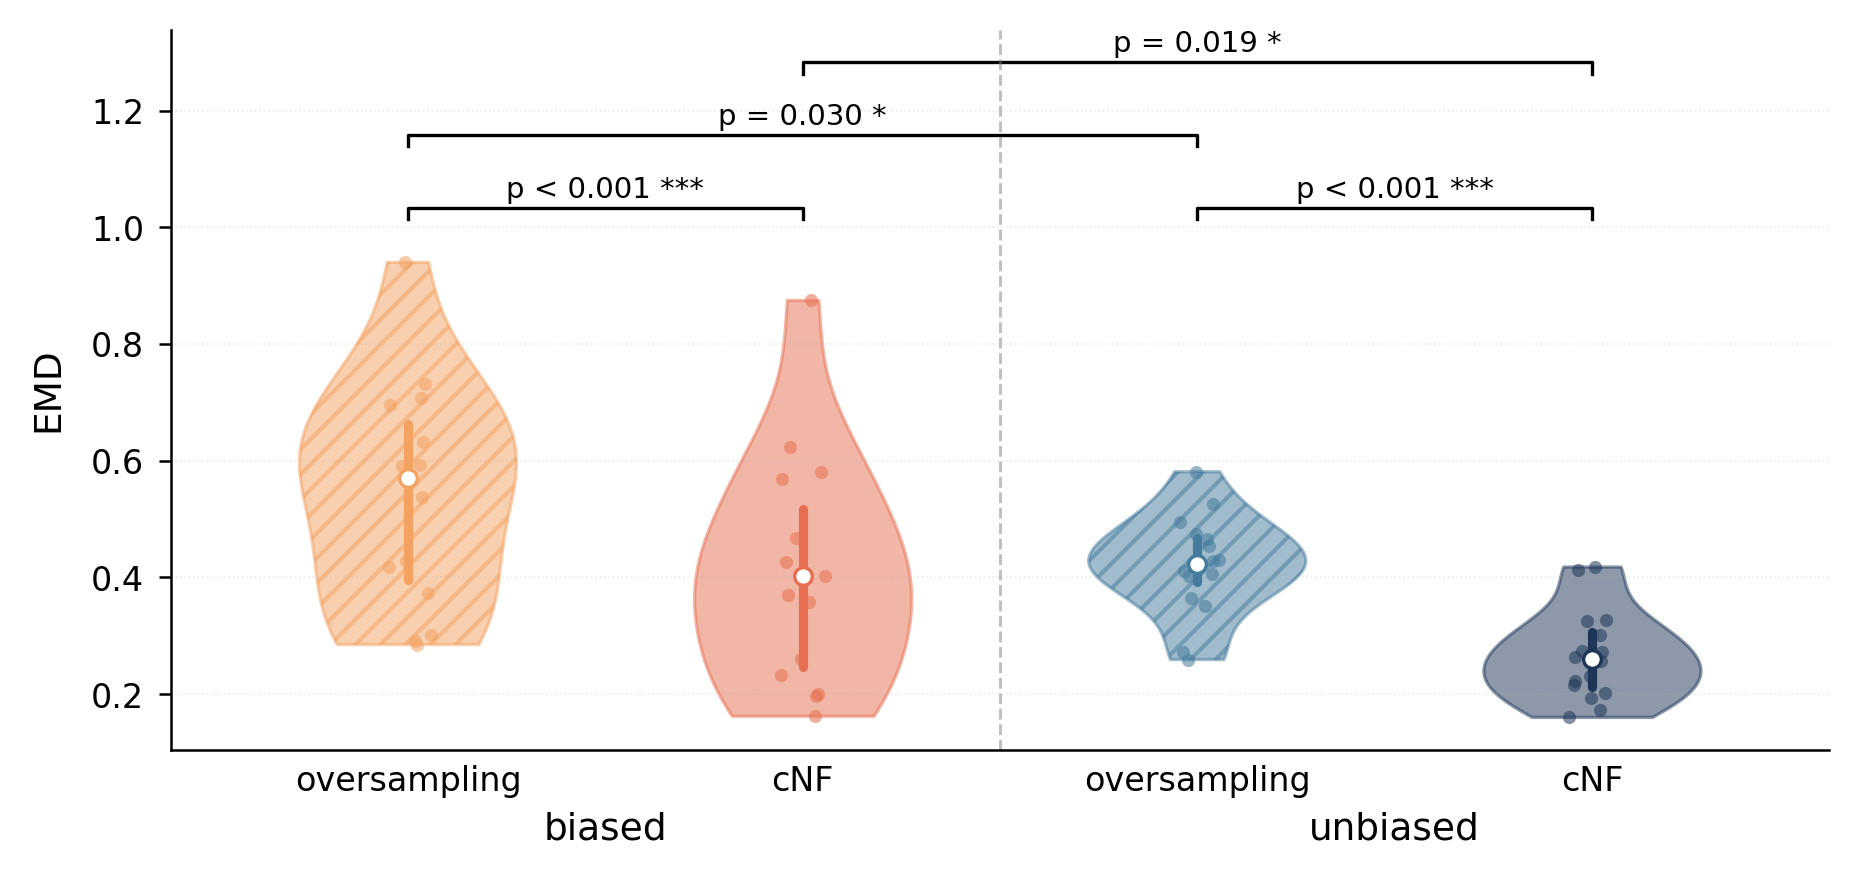

In [19]:
from scipy import stats

# ── variable filter ──────────────────────────────────────────────────────────
KEEP = {'log_exp', 'log_income', 'education_score', 'avg_adult_education',
        'space_per_person', 'wscore', 'log_exp_pp'}

RENAME = {
    'log_exp':            'Expenditures',
    'log_income':         'Income',
    'education_score':    'Education',
    'avg_adult_education':'Education',
    'space_per_person':   'Space pp',
    'wscore':             'Wealth Score',
    'log_exp_pp':         'Expenditures pp',
}

group_cols = ['target', 'experiment_id']

df_b = (df_biased[df_biased['target'].isin(KEEP)]
        .groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index())
df_u = (df_unbiased[df_unbiased['target'].isin(KEEP)]
        .groupby(group_cols)[['emd_over', 'emd_gen']].mean().reset_index())

merged_over = pd.merge(df_b[group_cols + ['emd_over']], df_u[group_cols + ['emd_over']],
                       on=group_cols, suffixes=('_b', '_u')).dropna()
merged_gen  = pd.merge(df_b[group_cols + ['emd_gen']],  df_u[group_cols + ['emd_gen']],
                       on=group_cols, suffixes=('_b', '_u')).dropna()
merged_within_b = df_b[['emd_over', 'emd_gen']].dropna()
merged_within_u = df_u[['emd_over', 'emd_gen']].dropna()

data = [
    df_b['emd_over'].dropna().values,
    df_b['emd_gen'].dropna().values,
    df_u['emd_over'].dropna().values,
    df_u['emd_gen'].dropna().values,
]

def pval_label(p):
    if p < 0.001: return "p < 0.001 ***"
    if p < 0.01:  return f"p = {p:.3f} **"
    if p < 0.05:  return f"p = {p:.3f} *"
    return f"p = {p:.3f} (n.s.)"

_, p_within_b = stats.ttest_rel(merged_within_b['emd_over'], merged_within_b['emd_gen'])
_, p_within_u = stats.ttest_rel(merged_within_u['emd_over'], merged_within_u['emd_gen'])
_, p_over     = stats.ttest_rel(merged_over['emd_over_b'],   merged_over['emd_over_u'])
_, p_gen      = stats.ttest_rel(merged_gen['emd_gen_b'],     merged_gen['emd_gen_u'])

print(f"n pairs (over): {len(merged_over)}  |  n pairs (gen): {len(merged_gen)}")

C       = ['#F4A261', '#E76F51', '#457B9D', '#1D3557']
HATCHES = ['////', None, '////', None]
XS      = [0, 1, 2, 3]
XLABELS = ['oversampling', 'cNF', 'oversampling', 'cNF']

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.subplots_adjust(left=0.12, right=0.97, top=0.78, bottom=0.18)

rng = np.random.default_rng(42)

for x, vals, col, hatch in zip(XS, data, C, HATCHES):
    parts = ax.violinplot(vals, positions=[x], widths=0.55,
                          showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(col)
        pc.set_edgecolor(col)
        pc.set_alpha(0.50)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    ax.plot([x, x], [q25, q75], color=col, linewidth=2.2,
            solid_capstyle='round', zorder=5)
    ax.scatter(x, med, color='white', s=18, zorder=6,
               linewidths=0.8, edgecolors=col)

    jitter = rng.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(x + jitter, vals, color=col, s=10, alpha=0.55,
               linewidths=0, zorder=3)

y_max = max(d.max() for d in data)
span  = y_max - min(d.min() for d in data)

def sig_bracket(ax, x1, x2, y, p):
    lbl = pval_label(p)
    col = 'black' if '(n.s.)' not in lbl else '0.55'
    tip = span * 0.025
    ax.plot([x1, x1, x2, x2], [y - tip, y, y, y - tip],
            color=col, linewidth=0.8)
    ax.text((x1 + x2) / 2, y + span * 0.01, lbl,
            ha='center', va='bottom', fontsize=7, color=col)

b0 = y_max + span * 0.12
b1 = b0    + span * 0.16
b2 = b1    + span * 0.16

sig_bracket(ax, 0, 1, b0, p_within_b)
sig_bracket(ax, 2, 3, b0, p_within_u)
sig_bracket(ax, 0, 2, b1, p_over)
sig_bracket(ax, 1, 3, b2, p_gen)

ax.axvline(1.5, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)

y_group = ax.get_ylim()[0] - span * 0.18 -0.05
for xc, lbl in [(0.5, 'biased'), (2.5, 'unbiased')]:
    ax.text(xc, y_group, lbl, ha='center', va='top',
            fontsize=9, 
            transform=ax.get_xaxis_transform())

ax.set_xticks(XS)
ax.set_xticklabels(XLABELS)
ax.tick_params(axis='x', length=0)
ax.set_xlim(-0.6, 3.6)
ax.set_ylabel('EMD', labelpad=6)

ax.grid(axis='y', linewidth=0.4, alpha=0.25, linestyle=':')

plt.savefig('/data/shared/fsibilla/clean_code/Q1/biased/comparew.pdf', dpi=400,bbox_inches="tight")


plt.show()

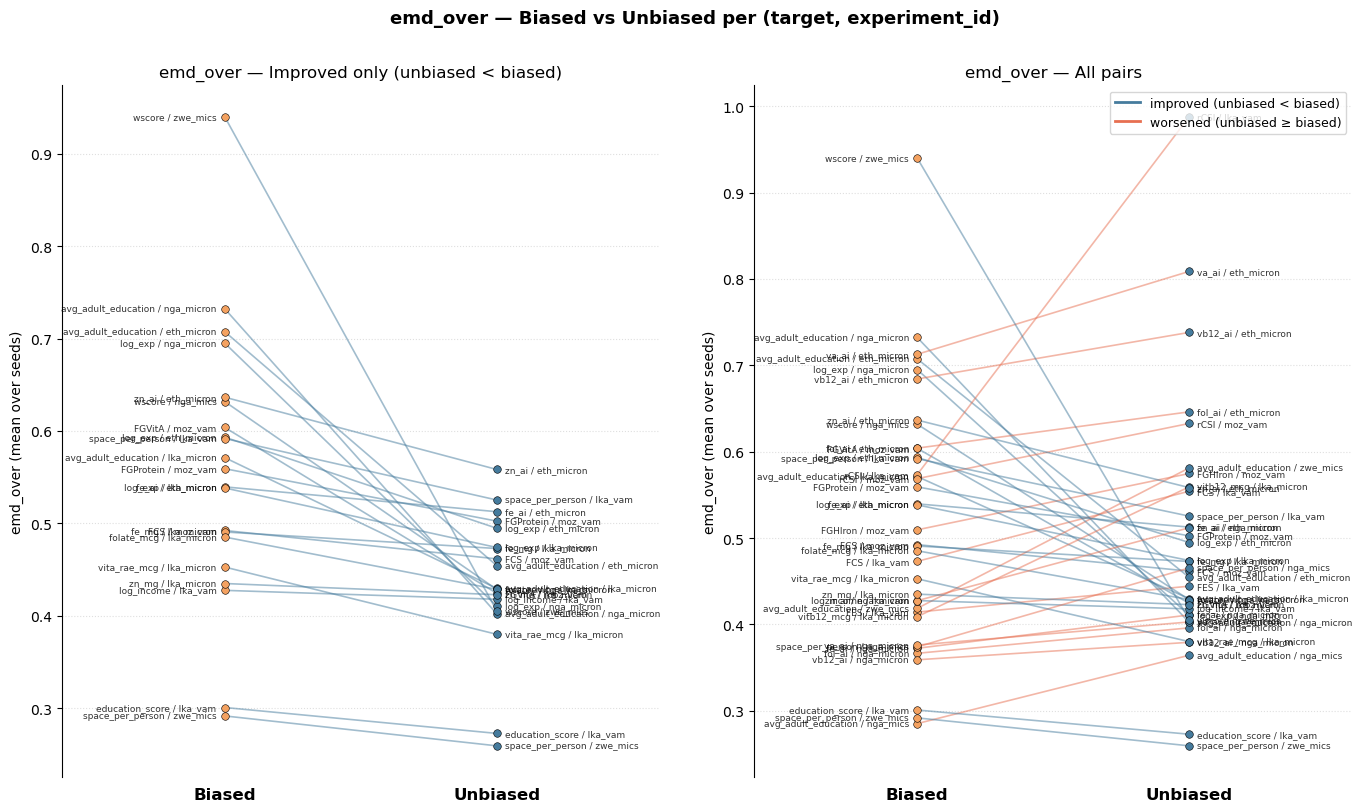

In [6]:
# ── Slopegraph: emd_over  biased → unbiased ──────────────────────────────────
group_cols = ['target', 'experiment_id']

df_b = (df_biased
        .groupby(group_cols)['emd_over']
        .mean()
        .reset_index()
        .rename(columns={'emd_over': 'biased'}))

df_u = (df_unbiased
        .groupby(group_cols)['emd_over']
        .mean()
        .reset_index()
        .rename(columns={'emd_over': 'unbiased'}))

merged = pd.merge(df_b, df_u, on=group_cols).dropna()
improved = merged['unbiased'] < merged['biased']
colors   = np.where(improved, '#457B9D', '#E76F51')

merged_neg = merged[improved].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

def draw_slopegraph(ax, data, title):
    imp = data['unbiased'] < data['biased']
    cols = np.where(imp, '#457B9D', '#E76F51')
    for (_, row), col in zip(data.iterrows(), cols):
        ax.plot([0, 1], [row['biased'], row['unbiased']],
                color=col, alpha=0.5, linewidth=1.2)
    ax.scatter(np.zeros(len(data)), data['biased'],
               color='#F4A261', edgecolor='black', linewidth=0.4, s=30, zorder=4)
    ax.scatter(np.ones(len(data)),  data['unbiased'],
               color='#457B9D', edgecolor='black', linewidth=0.4, s=30, zorder=4)
    for _, row in data.iterrows():
        label = f"{row['target']} / {row['experiment_id']}"
        ax.text(-0.03, row['biased'],   label, ha='right', va='center', fontsize=6.5, alpha=0.8)
        ax.text( 1.03, row['unbiased'], label, ha='left',  va='center', fontsize=6.5, alpha=0.8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Biased', 'Unbiased'], fontsize=12, fontweight='bold')
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel('emd_over (mean over seeds)')
    ax.set_title(title)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.xaxis.set_ticks_position('none')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

draw_slopegraph(axes[0], merged_neg, 'emd_over — Improved only (unbiased < biased)')
draw_slopegraph(axes[1], merged,     'emd_over — All pairs')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#457B9D', linewidth=2, label='improved (unbiased < biased)'),
    Line2D([0], [0], color='#E76F51', linewidth=2, label='worsened (unbiased ≥ biased)'),
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('emd_over — Biased vs Unbiased per (target, experiment_id)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()